# Notebook 02 — SAM2 연동: 텍스트 → 픽셀 마스크

> Grounding DINO(바운딩 박스) + SAM2(픽셀 마스크) 파이프라인

## 이 노트북에서 다루는 것

1. SAM2 작동 원리 — SAM1과 무엇이 다른가
2. HuggingFace SAM2 모델 로드
3. 바운딩 박스 → 픽셀 마스크 생성
4. DINO + SAM2 연결 파이프라인
5. 마스크 시각화 및 후처리

---

## 파이프라인 구조

```
텍스트 프롬프트
      ↓
Grounding DINO  →  바운딩 박스 (x1, y1, x2, y2)
      ↓
    SAM2        →  픽셀 마스크 (이진 세그멘테이션)
      ↓
  시각화 / 후처리
```

**SAM2 특징**:
- SAM1 대비 정확도 ↑, 속도 ↑
- 박스 / 포인트 / 마스크 프롬프트 지원
- 비디오 세그멘테이션 지원 (이번 노트북은 이미지만)

In [1]:
# 환경 설정
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image, ImageDraw

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGE_DIR = Path('../data/test_images')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'디바이스: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print('✅ 환경 설정 완료')

디바이스: cpu
PyTorch: 2.11.0+cpu
✅ 환경 설정 완료


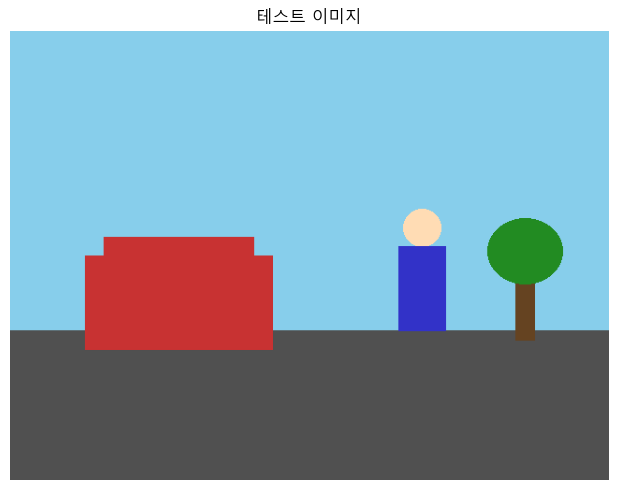

✅ 이미지 준비 완료


In [2]:
# 테스트 이미지 생성 (01 노트북과 동일)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

img = Image.new('RGB', (640, 480), color=(135, 206, 235))
draw = ImageDraw.Draw(img)
draw.rectangle([0, 320, 640, 480], fill=(80, 80, 80))
draw.rectangle([80, 240, 280, 340], fill=(200, 50, 50))
draw.rectangle([100, 220, 260, 250], fill=(200, 50, 50))
draw.ellipse([420, 190, 460, 230], fill=(255, 220, 180))
draw.rectangle([415, 230, 465, 320], fill=(50, 50, 200))
draw.rectangle([540, 260, 560, 330], fill=(101, 67, 33))
draw.ellipse([510, 200, 590, 270], fill=(34, 139, 34))
img.save(IMAGE_DIR / 'street.jpg', 'JPEG')

plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.title('테스트 이미지')
plt.axis('off')
plt.tight_layout()
plt.show()
print('✅ 이미지 준비 완료')

## 1. Grounding DINO 로드 (01 노트북과 동일)

In [3]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DINO_ID = 'IDEA-Research/grounding-dino-tiny'
dino_processor = AutoProcessor.from_pretrained(DINO_ID)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(DEVICE)
dino_model.eval()
print('✅ Grounding DINO 로드 완료')

def dino_detect(image_path, prompt, threshold=0.3):
    image = Image.open(image_path).convert('RGB')
    fmt = ' . '.join([w.strip().rstrip('.') for w in prompt.split('.') if w.strip()]) + '.'
    inputs = dino_processor(images=image, text=fmt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        outputs = dino_model(**inputs)
    results = dino_processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        threshold=threshold, text_threshold=threshold,
        target_sizes=[image.size[::-1]]
    )[0]
    return image, results

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

✅ Grounding DINO 로드 완료


## 2. SAM2 로드

- **모델 ID**: `facebook/sam2-hiera-tiny`
- HuggingFace transformers >= 4.44 필요
- 첫 실행 시 자동 다운로드 (~160 MB)

In [4]:
from transformers import Sam2Processor, Sam2Model

SAM2_ID = 'facebook/sam2-hiera-tiny'
print(f'SAM2 로드 중: {SAM2_ID}')

sam2_processor = Sam2Processor.from_pretrained(SAM2_ID)
sam2_model = Sam2Model.from_pretrained(SAM2_ID).to(DEVICE)
sam2_model.eval()

total_params = sum(p.numel() for p in sam2_model.parameters()) / 1e6
print(f'✅ SAM2 로드 완료  |  파라미터: {total_params:.1f}M  |  디바이스: {DEVICE}')

SAM2 로드 중: facebook/sam2-hiera-tiny


[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

✅ SAM2 로드 완료  |  파라미터: 31.4M  |  디바이스: cpu


## 3. SAM2 마스크 생성 함수

입력: `(image, boxes)` — DINO가 반환한 박스 좌표  
출력: `masks` — 각 박스에 대응하는 이진 마스크 (H×W)

In [5]:
def sam2_segment(image, boxes):
    """
    image : PIL.Image
    boxes : torch.Tensor shape (N, 4)  xyxy 절대 좌표
    returns: list of np.ndarray masks (H, W) bool
    """
    if len(boxes) == 0:
        return []

    boxes_list = boxes.cpu().tolist()

    inputs = sam2_processor(
        images=image,
        input_boxes=[boxes_list],
        return_tensors='pt'
    ).to(DEVICE)

    with torch.no_grad():
        outputs = sam2_model(**inputs)

    orig_sizes = inputs.get('original_sizes', None)
    if orig_sizes is None:
        orig_sizes = torch.tensor([[image.height, image.width]])

    # transformers 5.x: post_process_masks(masks, original_sizes) — reshaped_sizes 인자 없음
    masks = sam2_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        orig_sizes.cpu()
    )[0]  # (N, num_preds, H, W)

    iou_scores = outputs.iou_scores[0].cpu()  # (N, num_preds)
    best_masks = []
    for i in range(masks.shape[0]):
        best_idx = iou_scores[i].argmax().item()
        best_masks.append(masks[i, best_idx].numpy().astype(bool))

    return best_masks

print('✅ SAM2 세그멘테이션 함수 정의 완료')

✅ SAM2 세그멘테이션 함수 정의 완료


## 4. 시각화 함수

In [6]:
def show_masks(image, masks, labels, scores, title=''):
    """마스크 + 바운딩 박스 오버레이 시각화"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    img_arr = np.array(image)

    # 왼쪽: 마스크 오버레이
    overlay = img_arr.copy().astype(float)
    color_map = plt.cm.Set1(np.linspace(0, 1, max(len(masks), 1)))

    for i, mask in enumerate(masks):
        color = np.array(color_map[i][:3]) * 255
        overlay[mask] = overlay[mask] * 0.5 + color * 0.5

    axes[0].imshow(overlay.astype(np.uint8))
    axes[0].set_title(f'마스크 오버레이  ({len(masks)}개)')
    axes[0].axis('off')

    # 오른쪽: 개별 마스크
    axes[1].imshow(img_arr)
    for i, (mask, label, score) in enumerate(zip(masks, labels, scores)):
        color = color_map[i]
        # 마스크 윤곽선
        contour_mask = np.zeros((*mask.shape, 4))
        contour_mask[mask] = [*color[:3], 0.35]
        axes[1].imshow(contour_mask)
        # 라벨
        ys, xs = np.where(mask)
        if len(xs) > 0:
            cx, cy = xs.mean(), ys.mean()
            axes[1].text(cx, cy, f'{label}\n{score:.2f}',
                         ha='center', va='center', fontsize=9,
                         color='white', fontweight='bold',
                         bbox=dict(facecolor=color, alpha=0.7, pad=2))
    axes[1].set_title('라벨 + 마스크')
    axes[1].axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print('✅ 시각화 함수 정의 완료')

✅ 시각화 함수 정의 완료


## 5. DINO + SAM2 파이프라인 실행

Step 1: Grounding DINO 추론 중...


C:\Users\apple\Desktop\ai_agent_project\.venv\Lib\site-packages\transformers\models\grounding_dino\processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  감지된 객체: 3개
    1. tree (0.732)
    2. building (0.399)
    3. person (0.304)

Step 2: SAM2 세그멘테이션 중...
  마스크 생성: 3개
    1. tree — 면적: 5907px (1.9%)
    2. building — 면적: 23598px (7.7%)
    3. person — 면적: 6106px (2.0%)

Step 3: 시각화...


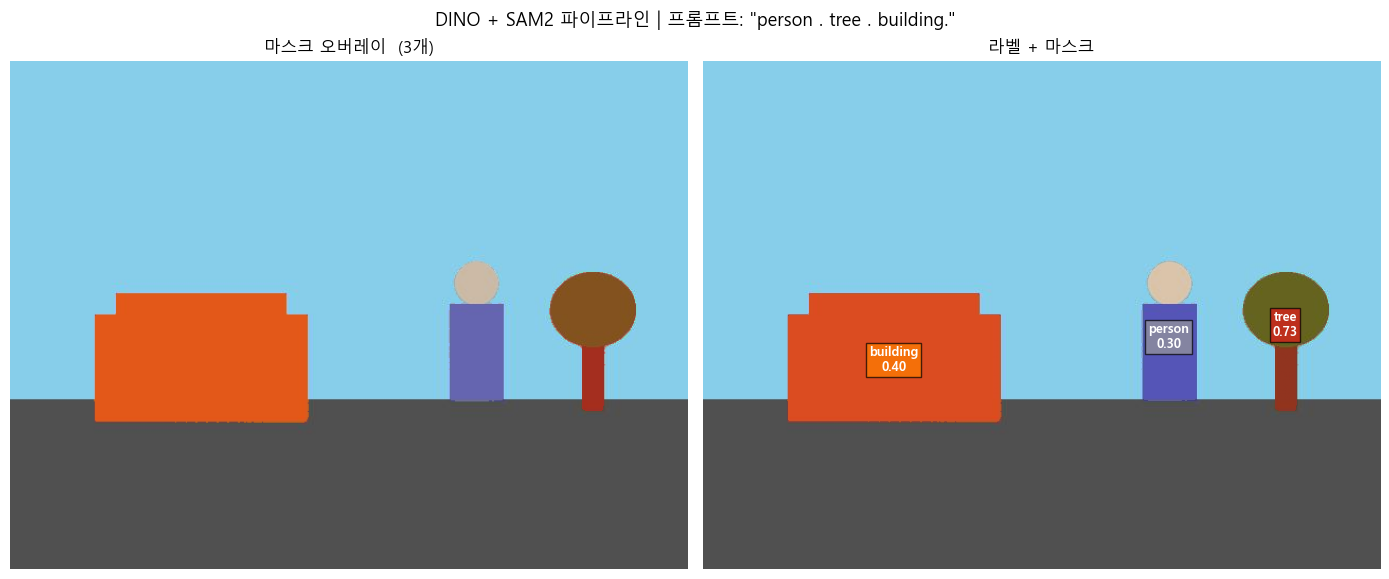

In [7]:
IMAGE_PATH = IMAGE_DIR / 'street.jpg'
PROMPT = 'person . tree . building.'
THRESHOLD = 0.2

# Step 1: Grounding DINO → 바운딩 박스
print('Step 1: Grounding DINO 추론 중...')
image, dino_results = dino_detect(IMAGE_PATH, PROMPT, threshold=THRESHOLD)
boxes  = dino_results['boxes']
labels = dino_results['labels']
scores = dino_results['scores']
print(f'  감지된 객체: {len(boxes)}개')
for i, (label, score) in enumerate(zip(labels, scores)):
    print(f'    {i+1}. {label} ({score:.3f})')

# Step 2: SAM2 → 픽셀 마스크
print('\nStep 2: SAM2 세그멘테이션 중...')
masks = sam2_segment(image, boxes)
print(f'  마스크 생성: {len(masks)}개')
for i, mask in enumerate(masks):
    area = mask.sum()
    total = mask.size
    print(f'    {i+1}. {labels[i]} — 면적: {area}px ({area/total*100:.1f}%)')

# Step 3: 시각화
print('\nStep 3: 시각화...')
show_masks(image, masks, labels, scores.tolist(),
           title=f'DINO + SAM2 파이프라인 | 프롬프트: "{PROMPT}"')

## 6. 결과 저장 — 마스크 PNG 추출

In [8]:
img_arr = np.array(image)
h, w = img_arr.shape[:2]

# 전체 마스크 합성 저장
combined = img_arr.copy().astype(float)
color_map = plt.cm.Set1(np.linspace(0, 1, max(len(masks), 1)))

for i, mask in enumerate(masks):
    color = np.array(color_map[i][:3]) * 255
    combined[mask] = combined[mask] * 0.4 + color * 0.6

result_img = Image.fromarray(combined.astype(np.uint8))
out_path = OUTPUT_DIR / '02_dino_sam2_result.png'
result_img.save(out_path)
print(f'✅ 저장: {out_path}')

# 개별 마스크 저장
for i, (mask, label) in enumerate(zip(masks, labels)):
    mask_img = Image.fromarray((mask * 255).astype(np.uint8))
    p = OUTPUT_DIR / f'02_mask_{i+1:02d}_{label.replace(" ", "_")}.png'
    mask_img.save(p)
    print(f'  마스크 저장: {p.name}')

print(f'\n총 {len(masks)+1}개 파일 저장 완료')

✅ 저장: ..\output\02_dino_sam2_result.png
  마스크 저장: 02_mask_01_tree.png
  마스크 저장: 02_mask_02_building.png
  마스크 저장: 02_mask_03_person.png

총 4개 파일 저장 완료


In [9]:
print('=' * 52)
print('Notebook 02 — SAM2 연동 완료')
print('=' * 52)
print()
print('[학습한 것]')
print('  1. SAM2: 박스 프롬프트 → 픽셀 마스크 생성')
print('  2. Grounding DINO → SAM2 연결 파이프라인')
print('  3. IOU score 기반 best mask 선택')
print('  4. 마스크 오버레이 시각화 + PNG 저장')
print()
print('[저장된 결과물]')
print('  - output/02_dino_sam2_result.png')
print('  - output/02_mask_XX_*.png  (개별 마스크)')
print()
print('[다음 노트북]')
print('  03_fastapi_serving.ipynb')
print('  → DINO + SAM2 파이프라인을 FastAPI로 서빙')

Notebook 02 — SAM2 연동 완료

[학습한 것]
  1. SAM2: 박스 프롬프트 → 픽셀 마스크 생성
  2. Grounding DINO → SAM2 연결 파이프라인
  3. IOU score 기반 best mask 선택
  4. 마스크 오버레이 시각화 + PNG 저장

[저장된 결과물]
  - output/02_dino_sam2_result.png
  - output/02_mask_XX_*.png  (개별 마스크)

[다음 노트북]
  03_fastapi_serving.ipynb
  → DINO + SAM2 파이프라인을 FastAPI로 서빙
